In [21]:
import numpy as np
from scipy.optimize import fsolve
from scipy.integrate import solve_ivp
import sys
from pathlib import Path
import importlib
# add Modeling/ to Python path
project_root = Path.cwd().parents[2]
sys.path.append(str(project_root))
import Modeling
importlib.reload(Modeling)
from Modeling.models.plotting import animate_field_1d
from Modeling.models.beam_properties import PiezoBeamParams


from Modeling.models import FE_helpers 
importlib.reload(FE_helpers)
import matplotlib.pyplot as plt
# from Modeling.models.ROM import ROM

import Modeling.models.FE3 as FE_module
importlib.reload(FE_module)
FE = FE_module


# Piezo-Beam FE Analysis with Arbitrary Region Types

## Simplified Geometry Definition

This notebook demonstrates a flexible approach to defining beam geometries with arbitrary material regions.

### Key Features:
1. **Define region types once** in a dictionary (substrate, piezo, Kapton, etc.)
2. **Specify layout** as a simple sequence: `['substrate', 'Kapton',  'piezo', 'Kapton', 'substrate', ...]`
3. **Set start positions** for each region: `[0, 5e-3, 30e-3, ...]`
   - Each region automatically ends where the next begins
   - Last region extends to beam length L
4. **Auto-detect piezos**: Any region type with "piezo" in its name is automatically treated as a piezo actuator/shunted

### Interface:
```python
region_types = {
    'substrate': {'EI': 1e-3, 'rhoA': 0.01, 'h': 5e-3},
    'piezo': {'EI': 5e-3, 'rhoA': 0.05, 'h': 2e-3},
    'mass': {'EI': 2e-2, 'rhoA': 0.5, 'h': 1e-3}
}

geom = build_geometry_from_types(
    L=0.4,
    region_types=region_types,
    region_sequence=['substrate', 'piezo', 'substrate', 'mass', 'piezo', 'substrate'],
    x_starts=[0, 0.05, 0.08, 0.15, 0.20, 0.23]
)
# Piezos at indices 1 and 4 are automatically detected by name
```


In [22]:

def compute_EI_and_rhoA(
	E_layers: np.ndarray,
	rho_layers: np.ndarray,
	h_layers: np.ndarray,
	b_layers: np.ndarray,
):
	"""
	Compute bending stiffness EI and mass per unit length mu
	for a symmetric layered beam.

	Layer ordering:
	- First layer is the mid-layer
	- Subsequent layers are stacked outward symmetrically

	Allows:
	- Different width for each layer
	"""

	E_layers = np.asarray(E_layers, dtype=float)
	rho_layers = np.asarray(rho_layers, dtype=float)
	h_layers = np.asarray(h_layers, dtype=float)
	b_layers = np.asarray(b_layers, dtype=float)

	assert len(E_layers) == len(h_layers) == len(rho_layers) == len(b_layers)
	y = [h_layers[0]/2]
	for i in range(1, len(h_layers)):
		y.append(y[i-1] + h_layers[i])
	EI = 0.0
	rhoA = 0.0
	for i, (E, b) in enumerate(zip(E_layers, b_layers)):
		if i==0:
			EI += E * b * y[i]**3 / 3 
			rhoA += rho_layers[i] * b * h_layers[i]/2
		else:
			EI += E * b * ( y[i] ** 3 - y[i-1] ** 3 )/3
			rhoA += rho_layers[i] * b * h_layers[i]

	assert len(y) == len(E_layers) == len(h_layers) == len(rho_layers) == len(b_layers)
	return 2*EI, 2*rhoA


In [23]:
# ============================================================
# Beam parameters 
# Here is wehre you can control strucural damping, and piezo properties
# ============================================================
params_fe = PiezoBeamParams(
    d31=-1.48e-10,        # Piezoelectric strain coefficient [m/V]
    eps_r=1700,           # Relative permittivity (dielectric constant)
    omega_p=2*np.pi*1,    # Lower frequency for Rayleigh damping [rad/s] (1 Hz)
    omega_q=2*np.pi*100   # Upper frequency for Rayleigh damping [rad/s] (100 Hz)
)
# Damping ratios at reference frequencies
params_fe.zeta_p = 0.05   # Modal damping ratio at omega_p (~5%)
params_fe.zeta_q = 0.2    # Modal damping ratio at omega_q (~20%)


# Material properties for different region types
L = 0.3             # beam length [m]
b_s = 100e-3          # substrate width [m]
b_p = 14e-3          # piezo width [m]
b_k = 25e-3          # kapton width [m]
h_s = 0.5e-3        # Substrate thickness [m]
h_p = 0.12e-3        # Piezo layer thickness [m]
h_k = 0.2e-3        # Kapton layer thickness [m] (for mass region)
rho_s = 1190       # Substrate density [kg/m³]
rho_p = 7800       # Piezo density [kg/m³]
rho_k = 1420       # Kapton density [kg/m³] (for mass region)
E_s = 3e9          # Substrate Young's modulus [Pa]
E_p = 31e9         # Piezo Young's modulus [Pa]
E_k = 3e9         # Kapton Young's modulus [Pa] (for mass region)
EI_kapton, rhoA_kapton = compute_EI_and_rhoA(E_layers=[E_s, E_k], rho_layers=[rho_s, rho_k], h_layers=[h_s, h_k], b_layers=[b_s, b_k])
EI_piezo, rhoA_piezo = compute_EI_and_rhoA(E_layers=[E_s, E_k, E_p], rho_layers=[rho_s, rho_k, rho_p], h_layers=[h_s, h_k, h_p], b_layers=[b_s, b_k, b_p])
print(f"Piezo: EI={EI_piezo:.2e} Nm², rhoA={rhoA_piezo:.2f} kg/m")
# Calculate properties for substrate (gap) regions
rhoA_substrate = b_s * rho_s * h_s
EI_substrate = b_s * E_s * h_s**3 / 12

print(f"Substrate: EI={EI_substrate:.2e} Nm², rhoA={rhoA_substrate:.2f} kg/m")
print(f"Piezo: EI={EI_piezo:.2e} Nm², rhoA={rhoA_piezo:.2f} kg/m")
print(f"Kapton (mass): EI={EI_kapton:.2e} Nm², rhoA={b_k * rho_k * h_k:.2f} kg/m")


Piezo: EI=3.41e-02 Nm², rhoA=0.10 kg/m
Substrate: EI=3.13e-03 Nm², rhoA=0.06 kg/m
Piezo: EI=3.41e-02 Nm², rhoA=0.10 kg/m
Kapton (mass): EI=6.90e-03 Nm², rhoA=0.01 kg/m


In [24]:
 
region_types = {
    'substrate': {'EI': EI_substrate, 'rhoA': rhoA_substrate, 'h': 1e-3 },
    'piezo': {'EI': EI_piezo, 'rhoA': rhoA_piezo, 'h': 5e-3},
    'kapton': {'EI': EI_kapton, 'rhoA': rhoA_kapton, 'h': 1e-3}
}
region_sequence = ['kapton','piezo','kapton','substrate',
                   'kapton','piezo','kapton','substrate',
                   'kapton','piezo','kapton','substrate',
                   'kapton','piezo','kapton','substrate',
                   'kapton','piezo','kapton','substrate'
                   ]
# x_starts = np.array([0, 4.5, 32.5, 37,
#                      40, 44.5, 72.5, 77,
#                      112.5, 124.5, 152.5, 164.5,
#                      192.5]) * 1e-3
                   
unit_cell = np.array([0, 4.5, 32.5, 37])*1e-3
x_starts = np.concatenate([unit_cell + i*40*1e-3 for i in range(5)])  # Repeat unit cell 5 times
 
# region_sequence = ['substrate','piezo',
#                    'substrate','piezo',
#                    'substrate','piezo',
#                    'substrate','piezo',
#                    'substrate','piezo',
#                    'substrate']
# x_starts = np.array([0, 4.5, 32.5,
#                      44.5, 72.5, 84.5,
#                      112.5, 124.5, 152.5, 164.5,
#                      192.5]) * 1e-3
 
geom = FE_module.build_geometry_from_types(L, region_types, region_sequence, x_starts)
# Automatically detects piezos at indices 1 and 4
 
params_fe.geometry = geom
 
# ============================================================
# Build finite element model
# ============================================================
fe = FE_module.PiezoBeamFE(params_fe)
 
# ============================================================
# Multi-piezo excitation setup with phase control
# ============================================================
j_exc = [0,1,2,3,4]  # Indices of excited (actuator) piezos
 
# Time-domain simulation parameters
t_end = 1         # Simulation duration [s]
f0 = 0.1           # Starting frequency for chirp [Hz]
f1 = 50          # Ending frequency for chirp [Hz]
dt = 1/f1/20       # Time step (20 samples per highest frequency period) [s]
 
# Excitation amplitudes for each piezo [V]
A1, A2, A3, A4, A5 = 1, 1, 1, 1, 1
 
# Phase offsets for each piezo [rad]
phase1, phase2, phase3, phase4, phase5 = np.pi/4, np.pi/4, np.pi/4, np.pi/4, np.pi/4  # 0°, 45°, 90°, 135°, 180°
 
def v_exc(t):
    """
    Multi-piezo chirp excitation with phase offsets.
    Each piezo gets a frequency sweep with different amplitude and phase.
   
    Returns:
        array: Voltage for each excited piezo at time t
    """
    v0 = A1 * np.sin(2*np.pi*(f0 + t*(f1-f0)/t_end) * t + phase1)
    v1 = A2 * np.sin(2*np.pi*(f0 + t*(f1-f0)/t_end) * t + phase2)
    v2 = A3 * np.sin(2*np.pi*(f0 + t*(f1-f0)/t_end) * t + phase3)
    v3 = A4 * np.sin(2*np.pi*(f0 + t*(f1-f0)/t_end) * t + phase4)
    v4 = A5 * np.sin(2*np.pi*(f0 + t*(f1-f0)/t_end) * t + phase5)
    # return np.array([v0])  # Single piezo excitation
    return np.array([v0, v1, v2, v3, v4])  # Five piezo excitation (uncomment for multi-piezo)
 
# Complex weights for frequency-domain analysis (amplitude * exp(i*phase))
phase_exc = np.array([phase1, phase2, phase3, phase4, phase5])
A_exc = np.array([A1, A2, A3, A4, A5])
weights_complex = A_exc * np.exp(1j * phase_exc)
 
# ============================================================
# Build ODE system with multi-piezo excitation
# ============================================================
ode = fe.build_ode_system(
    j_exc=j_exc,                           # Excited piezo indices
    R_c=1e3,                               # Circuit resistance [Ω]
    K_p=0,                              # Proportional feedback gain
    K_i=0,                             # Integral feedback gain
    K_c=0,                               # Cubic nonlinear gain (disabled)
    v_exc=v_exc,                            # Time-domain excitation function
    freq_domain_amps=weights_complex  # Complex weights for frequency-domain analysis
)
 
# ============================================================
# Frequency-domain FRF sweep
# ============================================================
f_fe = np.linspace(f0, f1, 500)                     # Frequency vector [Hz]
frf_fd = FE_helpers.frf_sweep(ode, f_fe*2*np.pi)   # Sweep (convert to rad/s)
 
# Extract frequency-domain results
N = ode.N_mech                                      # Number of mechanical DOFs
w_fd = frf_fd['u']                                  # Displacement FRF (complex)
w_dot_fd = frf_fd['u_dot']                          # Velocity FRF (complex)
freq_fd = frf_fd['freq']                            # Frequency vector [Hz]
vel_fd = np.mean(np.abs(w_dot_fd), axis=1)         # Spatially-averaged velocity magnitude
 
# ============================================================
# Time-domain simulation (Newmark-beta integration)
# ============================================================
# Initial conditions
ndof = ode.M.shape[0]                               # Total DOFs (mech + elec)
x0 = np.zeros(ndof)                                 # Zero initial displacement/charge
x_dot0 = np.zeros(ndof)                             # Zero initial velocity/voltage
 
# Run time integration
result = FE_helpers.solve_newmark(
    ode=ode,
    dt=dt,                                          # Time step [s]
    t_end=t_end,                                    # End time [s]
    beta=0.25,                                      # Newmark parameter (average acceleration)
    gamma=0.5,                                      # Newmark parameter (trapezoidal rule)
    newton_tol=1e-8,                                # Newton-Raphson convergence tolerance
    newton_maxiter=8,                               # Max Newton iterations per step
    x0=x0,
    x_dot0=x_dot0
)
 
# ============================================================
# Extract time-domain results
# ============================================================
t = result['t']                  # Time vector [s]
w = result['u']                  # Mechanical displacement [m]
w_dot = result['u_dot']          # Mechanical velocity [m/s]
w_ddot = result['u_ddot']        # Mechanical acceleration [m/s²]
q = result['q']                  # Electrical charge [C]
v = result['v']                  # Voltage [V]
spec_td = result['spectral']     # Time-domain FRF (FFT-based)
 
 # Time-domain FRF from FFT
freq_td = spec_td['freq']        # Frequency vector from FFT [Hz]
frf_td = spec_td['FRF']  
frf_td_y = np.mean(np.abs(spec_td['Y']), axis=1)

Newmark Integration: 100%|██████████| 1000/1000 [00:05<00:00, 180.29step/s]

X shape: (1001,) Y shape: (1001, 199) freq shape: (1001,) veloc shape: (1001, 199)


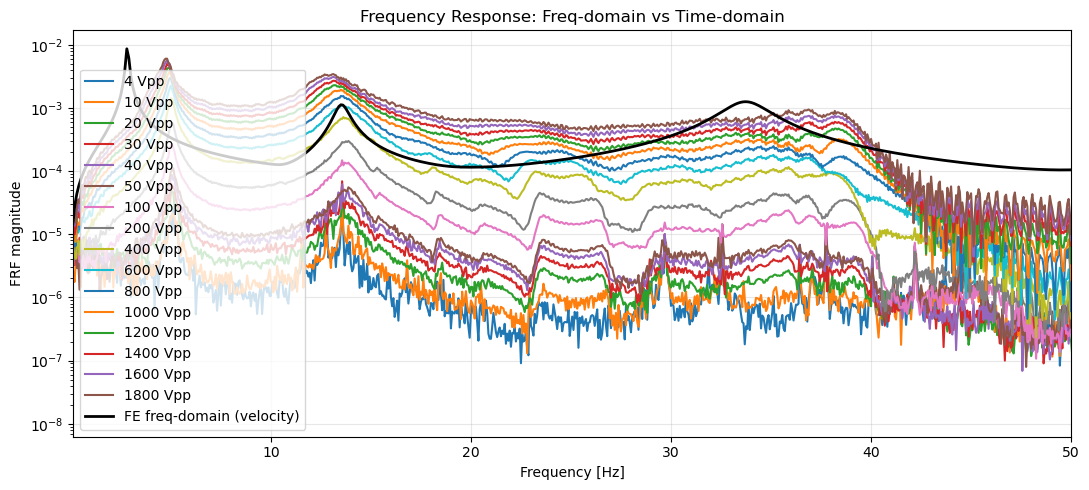

In [25]:
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt

# Set your Excel file path here
excel_path = Path("./MFC1_9-28_2025.xlsx")

if not excel_path.exists():
    raise FileNotFoundError(f"Excel file not found: {excel_path.resolve()}")

xls = pd.ExcelFile(excel_path)
plt.figure(figsize=(11, 5))

for sheet_name in xls.sheet_names:
    # Read first two columns only: frequency (col 1), velocity (col 2)
    df = pd.read_excel(excel_path, sheet_name=sheet_name, usecols=[0, 1])

    # Coerce non-numeric values (headers/empty rows) to NaN and drop them
    freq = pd.to_numeric(df.iloc[:, 0], errors="coerce")
    vel = pd.to_numeric(df.iloc[:, 1], errors="coerce")
    valid = freq.notna() & vel.notna()

    if valid.any():
        plt.semilogy(freq[valid], vel[valid], lw=1.5, label=sheet_name)

plt.xlabel("Frequency [Hz]")
plt.ylabel("Velocity")
plt.title(f"Frequency vs Velocity from all sheets\n{excel_path.name}")
plt.grid(True, alpha=0.3)
plt.legend(loc="best", fontsize=8, ncol=2)
plt.tight_layout()
# plt.show()
        # FRF magnitude (spatially averaged)

# ============================================================
# Plot FRF comparison (frequency vs time domain)
# ============================================================
# plt.figure(figsize=(10, 4))


plt.semilogy(freq_fd, vel_fd/1.2, 'k-', lw=2, label='FE freq-domain (velocity)')
# plt.semilogy(freq_td, frf_td/1.5, '.-', label='FE time-domain (velocity)')
plt.xlabel('Frequency [Hz]')
plt.ylabel('FRF magnitude')
plt.xlim([f0, f1])
plt.grid(True)
plt.legend()
plt.title('Frequency Response: Freq-domain vs Time-domain')
plt.tight_layout()
plt.show()

In [26]:
import pickle
import json
from datetime import datetime
from pathlib import Path

save_dir = Path('./sim_dat')
save_dir.mkdir(parents=True, exist_ok=True)


config = {
    "beam": {
        "L": L,
        "E_s": E_s,
        "E_p": E_p,
        "E_k": E_k,
        "rho_s": rho_s,
        "rho_p": rho_p,
        "rho_k": rho_k,
        "b_s": b_s,
        "b_p": b_p,
        "b_k": b_k,
        "h_s": h_s,
        "h_p": h_p,
        "h_k": h_k,
        "EI_substrate": float(EI_substrate),
        "EI_piezo": float(EI_piezo),
        "EI_kapton": float(EI_kapton),
        "rhoA_substrate": float(rhoA_substrate),
        "rhoA_piezo": float(rhoA_piezo),
        "rhoA_kapton": float(rhoA_kapton),
    },
    "geometry": {
        "region_types": region_types,
        "region_sequence": region_sequence,
        "x_starts": x_starts.tolist(),  # Convert numpy array to list
    },
    "excitation": {
        "j_exc": j_exc,
        "A_exc": A_exc.tolist() if hasattr(A_exc, 'tolist') else A_exc,
        "phase_exc": phase_exc.tolist() if hasattr(phase_exc, 'tolist') else phase_exc,
        "f0": f0,
        "f1": f1,
        "t_end": t_end,
        "dt": dt,
    },
    "controller": {
        "R_c": 1e3,
        "K_p": 0.02,
        "K_i": 0.001,
        "K_c": 0.0,
    },
    "solver": {
        "beta": 0.25,
        "gamma": 0.5,
        "newton_tol": 1e-8,
        "newton_maxiter": 8,
    },
}

results = {
    "frequency_domain": {
        "f_fe": f_fe,
        "freq_fd": freq_fd,
        "w_fd": w_fd,
        "w_dot_fd": w_dot_fd,
        "vel_fd": vel_fd,
        "frf_fd": frf_fd,
    },
    "time_domain": {
        "t": t,
        "w": w,
        "w_dot": w_dot,
        "w_ddot": w_ddot,
        "q": q,
        "v": v,
        "spec_td": spec_td,
        "raw_result": result,
    },
}

payload = {
    "config": config,
    "results": results,
}

out_file = save_dir / f"arbitrary_placement_{datetime.now().strftime('%Y%m%d_%H%M%S')}.pkl"

# Prevent overwriting: append counter if file exists
counter = 0
original_out_file = out_file
while out_file.exists():
    counter += 1
    out_file = save_dir / f"arbitrary_placement_{datetime.now().strftime('%Y%m%d_%H%M%S')}_{counter}.pkl"

with open(out_file, "wb") as f:
    pickle.dump(payload, f, protocol=pickle.HIGHEST_PROTOCOL)

# Also save config as human-readable JSON
config_file = out_file.with_stem(out_file.stem).with_suffix('.json')
with open(config_file, "w") as f:
    json.dump(config, f, indent=2, default=str)

print(f"Saved pickle: {out_file}")
print(f"Saved config: {config_file}")
if counter > 0:
    print(f"  (Avoided overwriting existing file, appended suffix _{counter})")

Saved pickle: sim_dat\arbitrary_placement_20260312_180333.pkl
Saved config: sim_dat\arbitrary_placement_20260312_180333.json


In [27]:
v_exc(t).shape

(5, 1001)

Saving frame 500/500Saved animation to ./anim/test.mp4


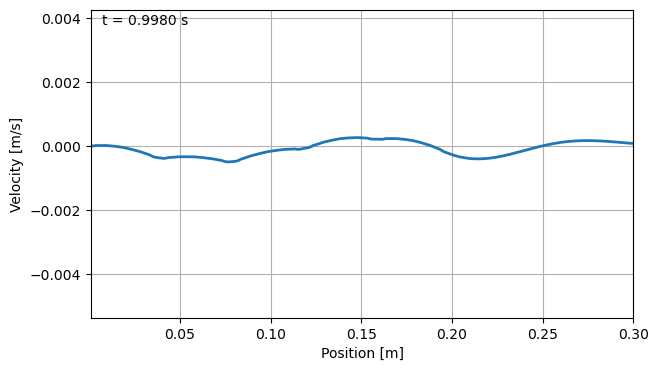

In [28]:
# After creating envelope_func and loading FE results
from Modeling.models import plotting
importlib.reload(plotting)

temporal_slice = slice(0, -1 )
plotting.animate_field_1d(
    t=t[temporal_slice],
    u=w_dot[temporal_slice],  # or w for displacement
    x=fe.geom.x_nodes[1:],  # spatial grid
    filename=f"./anim/test.mp4",
    scale=1.0,
    stride=2,
    ylabel="Velocity [m/s]",
    xlabel="Position [m]",
    fps=50,
    # y_lim_scale=0.8
)